In [ ]:
import sys
import os
import pytest

from tqdm.notebook import tqdm, trange
import jax
jax.config.update("jax_enable_x64", True)
import jax.tree as jtu
import jax.numpy as np
import jax.random as jr
from jax import Array
from jax.flatten_util import ravel_pytree
import equinox as eqx
from zodiax.diffops import hessian
from zodiax.optimisation import eigen_projection

from optax import sgd, adam
import optimistix as optx

import amigo as amg
from amg.stats import bin_data
import dorito as drt
from dorito.model_fits import PointResolvedFit as prf
from dorito.bases import ImageBasis
from dorito.model_fits import ResolvedOIFit
from dorito.model_fits import _OIFit
from dorito.models import ResolvedAmigoModel
from dorito.models import ResolvedDiscoModel
from dorito.bases import ImageBasis
from dorito.models import BaseModeller
from dorito.stats import disco_regularised_loss_fn


from kneed import KneeLocator

import dLux.utils as dlu

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch
import ehtplot
import scienceplots
import cmasher as cmr

plt.style.use(["science", "bright", "no-latex"])
new_rcParams = {
    "svg.fonttype": "none",
    "image.cmap": "inferno",
    "font.family": "serif",
    "image.origin": "lower",
    "figure.dpi": 300,
    "font.size": 8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

from frito.autoencoder.ae_utils import load_classes_from_file as lcf, run_svd
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
)
from frito.jax_gaussian import gaussian_filter
from frito.plot import main_mosaic
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
    disco_regularised_loss_forecast_fn as drl_forecast_fn,
    oi_log_likelihood_forecast as oi_ll_forecast,
    latent_gaussian_prior as lgp,
)

In [2]:
master_key = jr.key(42)
main_data_path = "_data"
autoencoder_data_path = os.path.join(main_data_path, "autoencoder")
main_trained_model_path = os.path.join(autoencoder_data_path, "trained_models")
main_svd_path = os.path.join(autoencoder_data_path, "svd")
training_data_path = os.path.join(autoencoder_data_path, "training_data")
emnist_path = os.path.join(training_data_path, "emnist.npz")
mnist_path = os.path.join(training_data_path, "mnist.npz")
ppd_51_path = os.path.join(training_data_path, "fake_intensity_PPDs_51x51.npz")

main_out_path = "_output"
main_model_struct_path = "src/frito/autoencoder/model_structures"

ppd_51x51_data = np.load(ppd_51_path)
test_51x51_data = ppd_51x51_data["x_test"]

disco_HD100546_path = os.path.join(
    main_data_path, "jwst", "HD100546", "disco", "cal_vis_HD-100546.npy"
)
disco_HD135344B_path = os.path.join(
    main_data_path, "jwst", "HD135344B", "disco", "cal_vis_HD135344B.npy"
)
disco_PDS70_path = os.path.join(
    main_data_path, "jwst", "PDS70", "disco", "bgmask_cal_vis_pds70.npy"
)

In [3]:
disco_PDS70 = np.load(disco_PDS70_path, allow_pickle=True).item()
disco_HD100546 = np.load(disco_HD100546_path, allow_pickle=True).item()
disco_HD135344B = np.load(disco_HD135344B_path, allow_pickle=True).item()

In [ ]:
source_name = "PDS70"
data_path = f"_data/JWST/{source_name}/calslope/"#os.path.join(path, )
# uncal_path = os.path.join(path, f"data/JWST/{source_name}/uncal/")
amigo_cache = "_data/amigo"

# cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, f"outputs/{source_name}/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amg.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# %% [markdown]
#
# # Loading in data

# %%
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1#

    if file[0].header["TARGPROP"] == "TD-PDS-70":
        # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
        file["BADPIX"].data[17, 70] = 1
        file["BADPIX"].data[19, 53] = 1
        file["BADPIX"].data[5, 22] = 1
        file["BADPIX"].data[19, 41] = 1
        # file["BADPIX"].data[:66, :25] = 1  # BACKGROUND STAR?
        file["BADPIX"].data[76, 45] = 1
        file["BADPIX"].data[59, 30] = 1

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(sci_files, 30)

# %%
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}, Groups: {h["NGROUPS"]}, Ints: {h["NINTS"]}'
    )
    t0 = t


------------------------------

HD 228337 F480M, Dither 1/1, Roll 302.2deg, 15.2min, 2023-02-24 19:20:03.505, Groups: 29, Ints: 418
TD-PDS-70 F480M, Dither 1/1, Roll 301.7deg, 50.5min, 2023-02-24 21:05:03.720, Groups: 96, Ints: 418


/Users/jonahgoldfine/Documents/Important Documents/packages/frito/.venv/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [79]:
source_size = 121  # pixels
basis, window = drt.bases.inscribed_annulus_basis(source_size, iterations=1)
init_dist = np.ones((source_size, source_size)) / window.sum() # pixels
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

# sci_fits = [dorito.model_fits.MCAFit(file, use_cov=True) for file in sci_files]
sci_fits = [drt.model_fits.PointResolvedFit(file) for file in sci_files]
# sci_fits = []
cal_fits = [amg.model_fits.PointFit(file) for file in cal_files]
exps = sci_fits + cal_fits  

# building the model
model = drt.models.TransformedResolvedModel(
    exposures=exps,
    optics=amg.optical_models.AMIOptics(),
    detector=amg.detector_models.LinearDetector(),
    ramp_model=amg.ramp_models.NonLinearRamp(),
    read=amg.read_models.ReadModel(),
    state=load_dict(amigo_cache + /"calibration.npy"),
    basis=basis,
    window=window,
    param_initers={"contrast": 0.04, "distribution": init_dist},
)
    # moat_width=1,

SyntaxError: invalid syntax (389226920.py, line 19)

File 01242_005_02_03_1
Star TD-PDS-70
Filter F480M
nints 418
ngroups 96



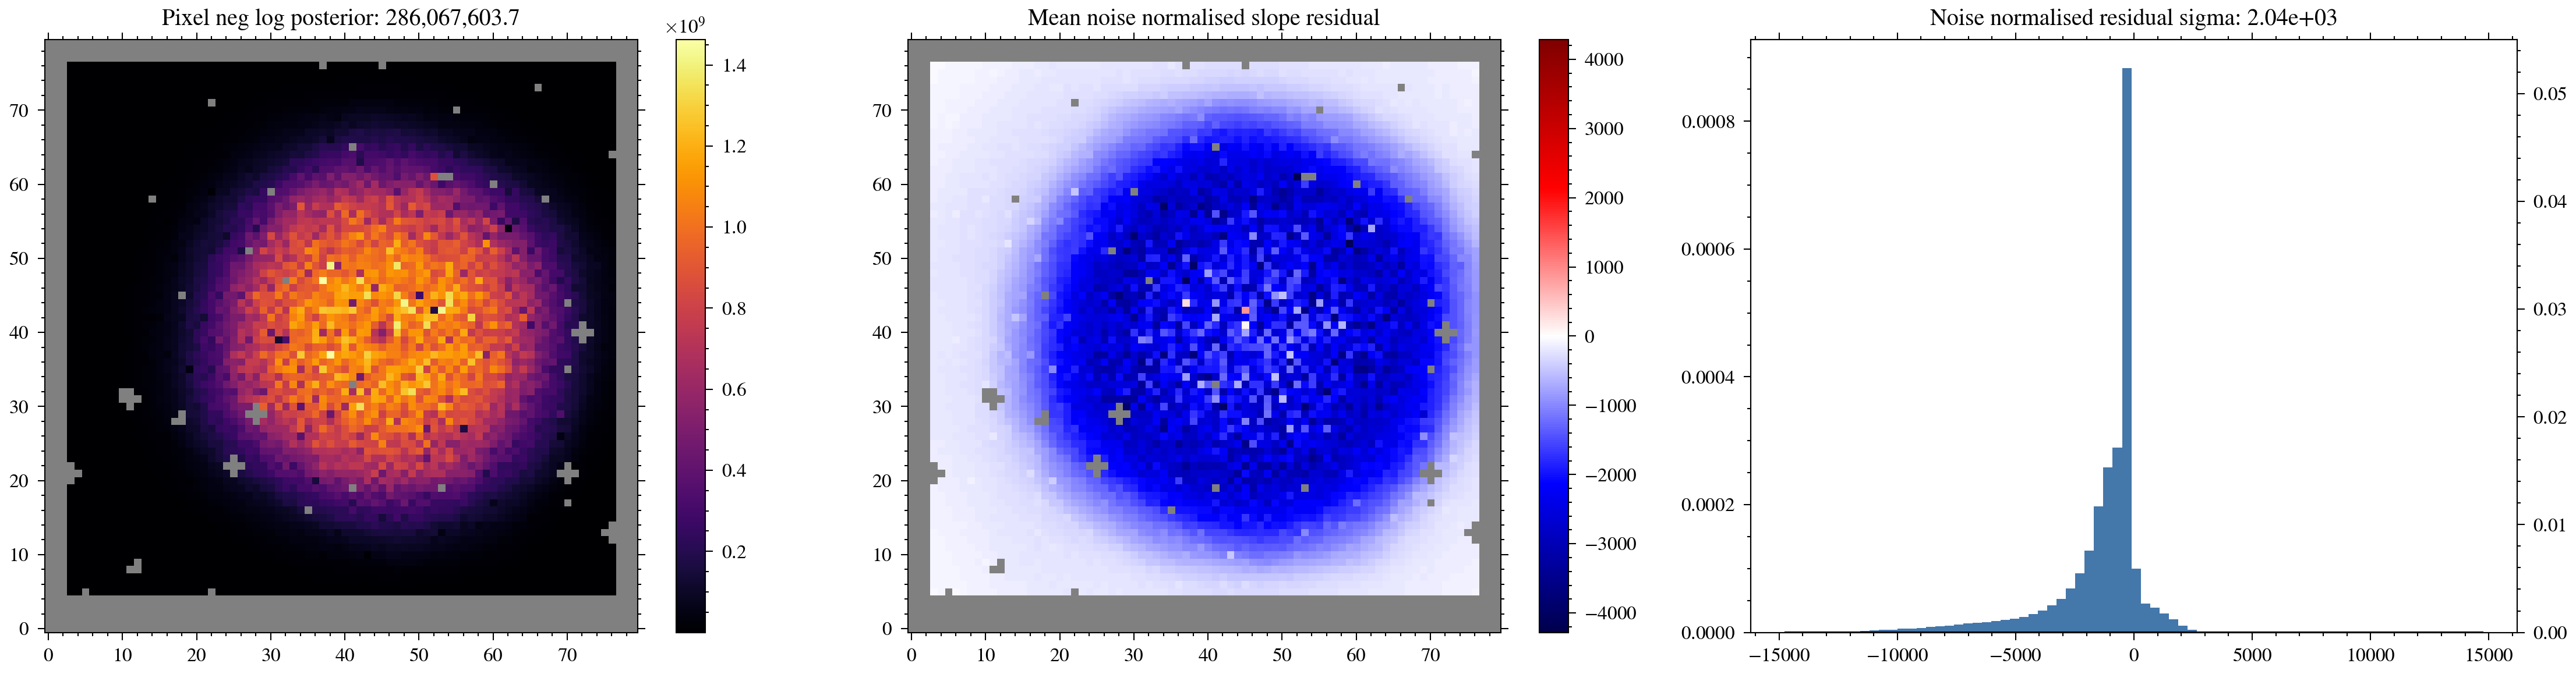

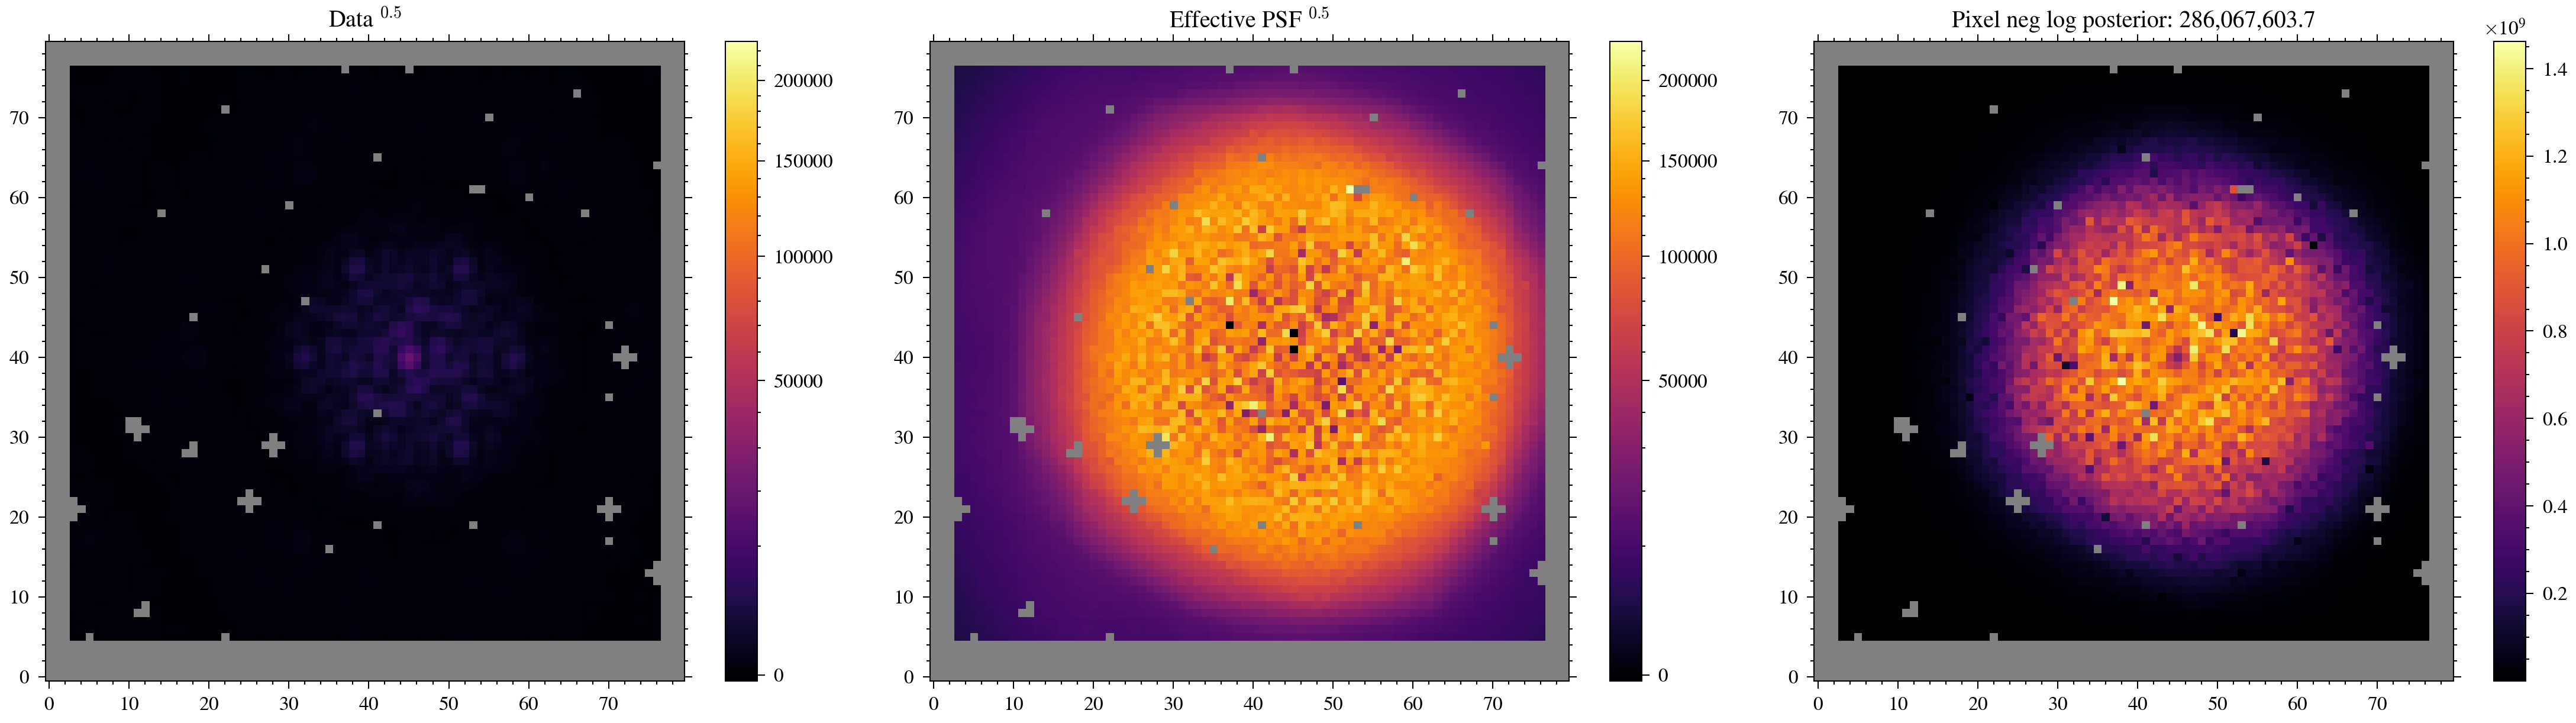

File 01242_004_02_03_1
Star HD 228337
Filter F480M
nints 418
ngroups 29



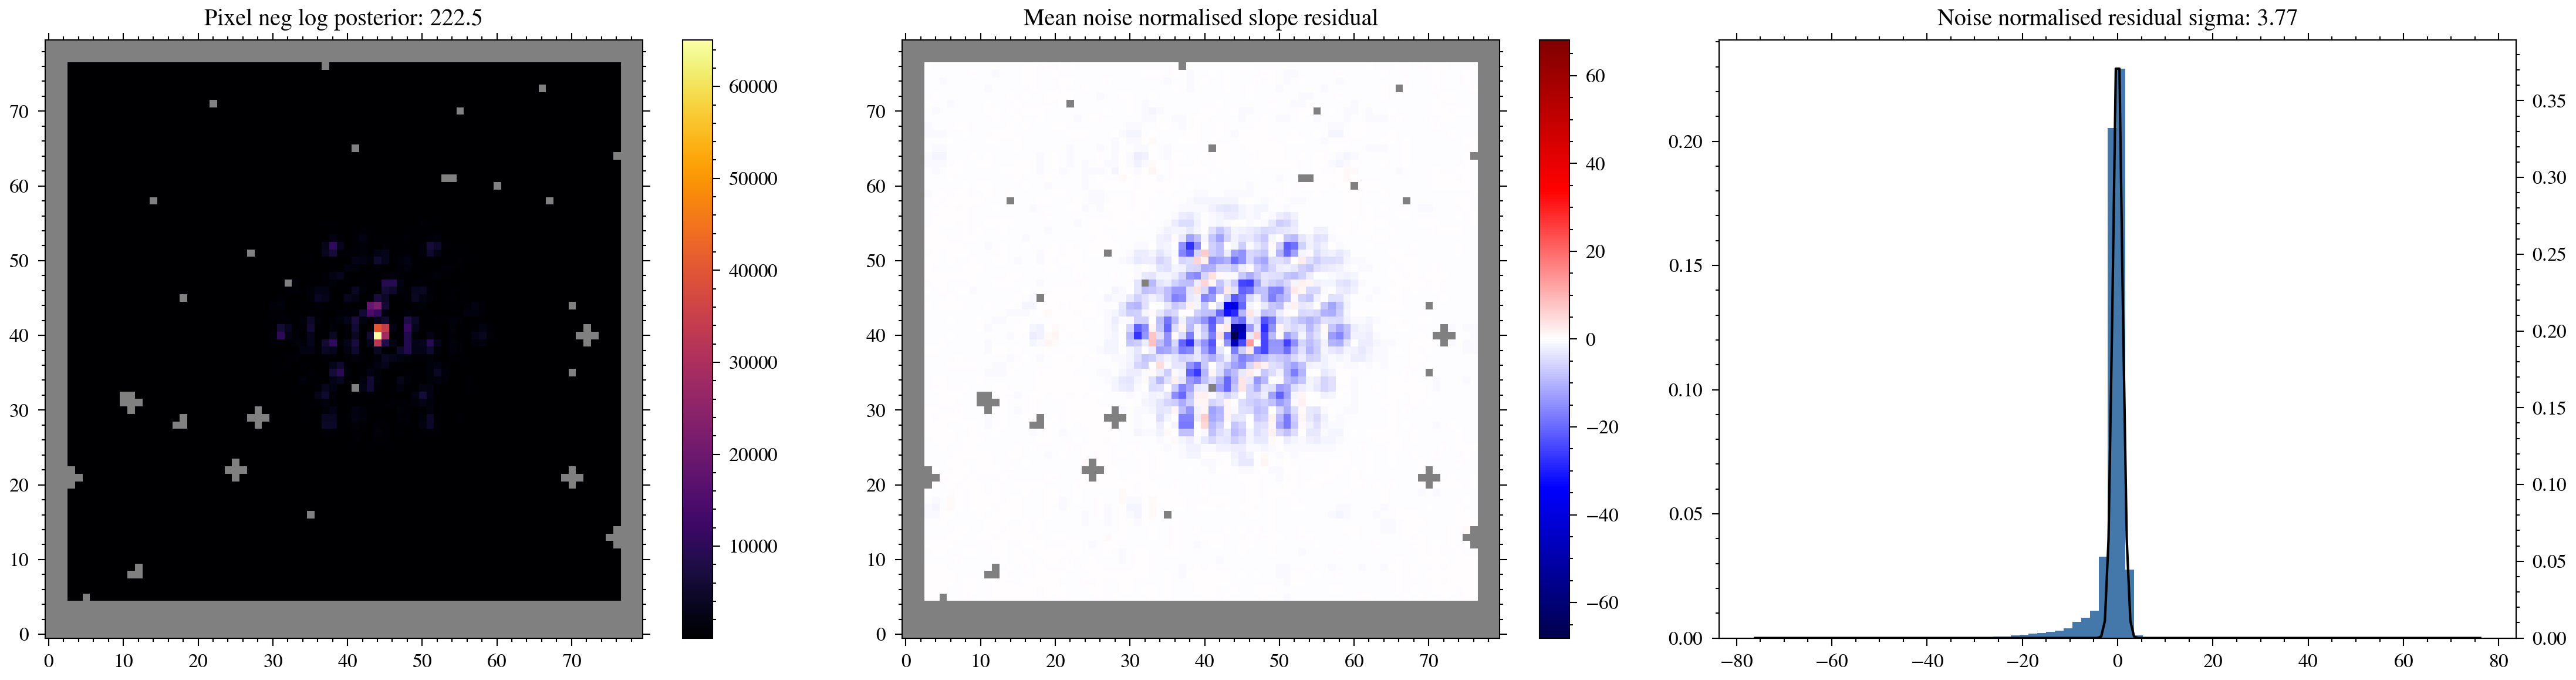

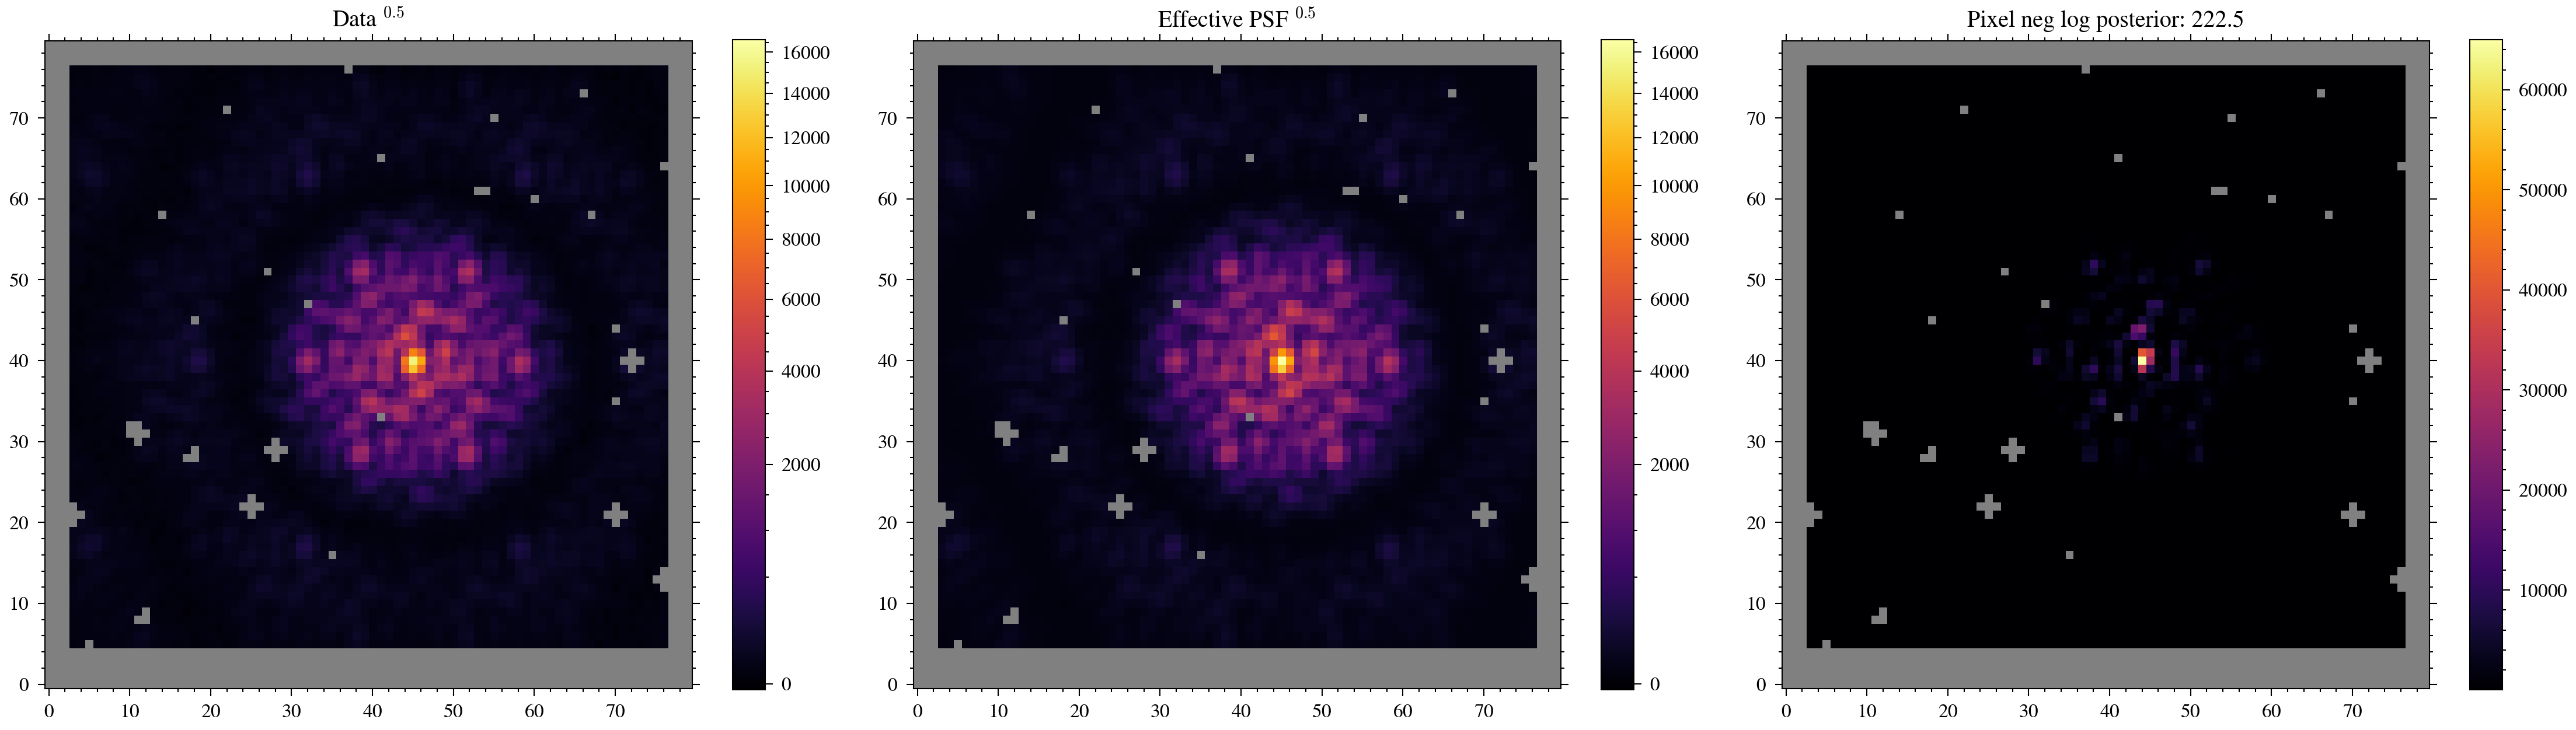

In [80]:
for exp in exps:
    exp.print_summary()
    amg.plotting.summarise_fit(model, exp, residuals=True)

In [86]:
pos_keys = []
spc_keys = []
flx_keys = []
for exp in exps:
    if not exp.calibrator:
        spc_keys.append(exp.map_param("spectra"))
        pos_keys.append(exp.map_param("positions"))
        flx_keys.append(exp.map_param("fluxes"))

def norm_fn(model_params, args):
    params = model_params.params

    # NOTE: This normalisation won't work for an arbitrary basis!
    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist
            log_dist = np.log10(distribution / distribution.sum())

            # basis = args["basis"]
            # window = args["window"]
            # distribution = 10 ** basis.from_basis(log_dist) * window
            # distribution = gaussian_filter(distribution, sigma=sig)
            # distribution += 1e-16 * ((window + 1) % 2)
            # log_dist = np.log10(distribution / distribution.sum())
            # log_dist = basis.to_basis(log_dist)
            params["log_dist"][k] = log_dist

    if "spectra" in params.keys():
        spectra = jax.tree.map(
            lambda x: np.clip(x, min=-0.8, max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args


pscale = lambda model: model.optics.psf_pixel_scale / model.optics.oversample

In [87]:
n_epoch = 100

config = {
    "positions": sgd(3e-3, 0),
    "fluxes": sgd(2e-2, 0),
    "aberrations": sgd(2e-2, 4),
    "spectra": sgd(4e-2, 10),
    "log_dist": adam(2e-1, 10),
    # "log_dist": adam(5e-1, 30),
    "contrast": adam(2e-2, 15),
    # "log_dist": adam(5e-2, 0),
    # "fluxes": sgd(2e-2, 0),
}


def grad_fn(model, grads, args):
    # Nuke the position gradients for the science exposures
    # if "positions" in config.keys():
        # grads = grads.multiply(sci_pos_keys, 0.0)

    # Reduce spectra gradients for the science exposures
    # if "spectra" in config.keys():
        # grads = grads.multiply(sci_spc_keys, 1e-2)
    return grads, args

In [88]:
args = {
    "reg_dict": {
        # "ME": (5e0, dorito.stats.ME),
        # "TV": (1e-2, dorito.stats.TV),
        # "TV": (1e-2, logTV),
        # "TV": (1e0, dorito.stats.TV),
    },
    "source_id": "TD",
    "basis": basis,
    "window": window,
}

In [89]:
trainer = amg.fitting.Trainer(
    loss_fn=drt.stats.ramp_regularised_loss_fn,
    norm_fn=norm_fn,
    # grad_fn=grad_fn,
    cache=os.path.join(amigo_cache, "fishers/"),
)

print("Populating fishers...")
trainer = trainer.populate_fishers(
    model,
    exps,
    hessians=load_dict(amigo_cache + "/jacobians.npy")["hessian"],
    parameters=[p for p in config.keys() if p not in ["log_dist", "contrast"]],
)

print("Number of exposures: ", len(exps))

Populating fishers...
Number of exposures:  2


In [90]:
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=exps,
    args=args,
)


  0%|          | 0/100 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 143,033,894.64
Estimated run time: 0:03:56


EquinoxRuntimeError: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/jonahgoldfine/Documents/Important Documents/packages/frito/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/jonahgoldfine/Documents/Important Documents/packages/frito/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/jonahgoldfine/Documents/Important Documents/packages/frito/.venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/Users/jonahgoldfine/Documents/Important Documents/packages/frito/.venv/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/Library/Frameworks/Python.framework/Versions/3.11/l